## Step 1: Import the required libraries

In [1]:
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv("Loan_Default.csv")

## Step 2: Shape and Type check

In [3]:
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [4]:
df.shape

(148670, 34)

In [5]:
df.dtypes

ID                             int64
year                           int64
loan_limit                    object
Gender                        object
approv_in_adv                 object
loan_type                     object
loan_purpose                  object
Credit_Worthiness             object
open_credit                   object
business_or_commercial        object
loan_amount                    int64
rate_of_interest             float64
Interest_rate_spread         float64
Upfront_charges              float64
term                         float64
Neg_ammortization             object
interest_only                 object
lump_sum_payment              object
property_value               float64
construction_type             object
occupancy_type                object
Secured_by                    object
total_units                   object
income                       float64
credit_type                   object
Credit_Score                   int64
co-applicant_credit_type      object
a

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

## Step 3: Missing Value Analysis

In [7]:
missing = df.isnull().sum()[df.isnull().sum() > 0]
pct = (missing/len(df)*100).round(2)
dtypes = df[df.columns[df.isnull().sum()>0]].dtypes

missing_data_summary = pd.DataFrame({
    'missing_count' : missing,
    'Missing %' : pct,
    'data_type' : dtypes
}).sort_values('Missing %', ascending = False)

missing_data_summary

,missing_count,Missing %,data_type
Upfront_charges,39642,26.66,float64
Interest_rate_spread,36639,24.64,float64
rate_of_interest,36439,24.51,float64
dtir1,24121,16.22,float64
property_value,15098,10.16,float64
LTV,15098,10.16,float64
income,9150,6.15,float64
loan_limit,3344,2.25,object
approv_in_adv,908,0.61,object
age,200,0.13,object


#### Here missing features names are listed. None of the features have missing % greater than 60%. Hence no need to drop that feature. 

In [8]:
num_column = df.select_dtypes(include=['number']).columns.tolist()
object_column = df.select_dtypes(include=['object']).columns.tolist()

In [9]:
print(f"There are {len(num_column)} columns with numerical data type and {len(object_column)} columns with object datatype.")

There are 13 columns with numerical data type and 21 columns with object datatype.


In [10]:
k = df[object_column].isnull().sum()[df[object_column].isnull().sum() > 0]
print(f"List of object columns with missing data:")
for i in range(len(k)):
    print(k.index[i])
    
print("\n")

m = df[num_column].isnull().sum()[df[num_column].isnull().sum() > 0]
print(f"List of numerical columns with missing data:")
for i in range(len(m)):
    print(m.index[i])

List of object columns with missing data:
loan_limit
approv_in_adv
loan_purpose
Neg_ammortization
age
submission_of_application


List of numerical columns with missing data:
rate_of_interest
Interest_rate_spread
Upfront_charges
term
property_value
income
LTV
dtir1


In [82]:
def missing_value_audit(df, target_col, num_anchor_col = None, mnar_ratio = 2.0, mar_diff_pct = 10.0, mnar_effect_threshold = 0.1, mar_effect_threshold = 0.1):
    
    records = []

    #Step 1: Splitting the data into missing columns list and anchor columns list
    if num_anchor_col is None:
        #Anchor column list
        num_anchor_col = [c for c in df.select_dtypes(include = ['number']).columns if c != target_col and df[c].isnull().sum() == 0]
    else:
        #Validation step if anchor list is provided
        clean_anchor = []
        for ac in num_anchor_col:
            n_miss = df[ac].isnull().sum()
            if n_miss > 0:
                print(f"Warning: {ac} column has {n_miss} missing value. Excluded from the anchor columns")
            else:
                clean_anchor.append(ac)
                
        num_anchor_col = clean_anchor

    #Missing column list
    missing_col = [m for m in df.columns if m != target_col and df[m].isnull().sum() > 0]

    #Step2: Checking every missing column and categorize them to one of the missing value type
    for col in missing_col:
        #Step a: Separating the column data into missing and not missing
        present_mask = df[col].notnull()
        missing_mask = df[col].isnull()

        #Step b: Calculating number of missing values, non-missing values and missing percentage
        n_missing = missing_mask.sum()
        n_present = present_mask.sum()
        missing_pct = round(n_missing / len(df)*100, 2)
        
        #Step C: Check 1 - Calculate rate ratio against target (Required for checking tendency towards MNAR and the strength)
        rate_present = df.loc[present_mask,target_col].mean()
        rate_missing = df.loc[missing_mask,target_col].mean()
        
        #rate_ratio
        if rate_present > 0:
            rate_ratio = round(max(rate_present,rate_missing) / min(rate_present,rate_missing), 2)
        else:
            rate_ratio = float('inf')

        #Mann-Whitney test for strength check
        group_present = df.loc[present_mask, target_col]
        group_missing = df.loc[missing_mask, target_col]

        stat, p_mnar = mannwhitneyu(group_present, group_missing, alternative='two-sided')
        n0, n1 = len(group_present), len(group_missing)
        effect_mnar = abs(1 - (2 * stat) / (n0 * n1))  # rank-biserial effect size
        
        
        #Step D: Check 2 - Calculate Mean difference on anchor column (Required for checking tendency towards MAR)
        best_diff_pct = 0
        best_anchor = None
        best_effect_anch = 0
        best_p_anch = 1.0
        
        for anch in num_anchor_col:
            anch_present = df.loc[present_mask, anch]
            anch_missing = df.loc[missing_mask, anch]

            if len(anch_missing) < 10: #Pragmatic common 10. We can change this 10 as according to number of rows available
                continue
            
            mean_present = anch_present.mean()
            mean_missing = anch_missing.mean()

            if mean_present == 0:
                continue
            
            diff_pct = abs(mean_present - mean_missing) / mean_present * 100

            if diff_pct > best_diff_pct:
                best_diff_pct = round(diff_pct, 1)
                best_anchor = anch

            # Mann-whitney strength check
            stat, p_anch = mannwhitneyu(anch_present, anch_missing, alternative='two-sided')
            n0, n1 = len(anch_present), len(anch_missing)
            effect_anch = abs(1 - (2 * stat) / (n0 * n1))

            if effect_anch > best_effect_anch:
                best_effect_anch = round(effect_anch, 4)
                best_p_anch = round(p_anch, 5)
                best_diff_pct = round(diff_pct, 1)
                best_anchor = anch

        
        #For MAR on categorical columns
        cat_anchor_cols = [c for c in df.select_dtypes(include='object').columns 
                   if c != target_col and df[c].isnull().sum() == 0]

        best_cat_p = 1.0
        best_cat_anchor = None
        best_cat_cramerv = 0

        n = len(df)
        for anch in cat_anchor_cols:
            contingency = pd.crosstab(df[anch], missing_mask)
            chi2, p, _, _ = chi2_contingency(contingency)
            cramer_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
            
            if cramer_v > best_cat_cramerv:
                best_cat_cramerv = round(cramer_v, 4)
                best_cat_p = round(p, 5)
                best_cat_anchor = anch

        
        mnar_detected = (p_mnar < 0.05) and (effect_mnar >= mnar_effect_threshold)  # default 0.1
        mar_num_detected = (best_p_anch < 0.05) and (best_effect_anch >= mar_effect_threshold)  # default 0.1
        mar_cat_detected = (best_cat_p < 0.05) and (best_cat_cramerv >= 0.05)
        
        
        #Suggest type
        if n_missing < 50:
            suggested_type = 'MCAR'
            suggested_action = 'Drop row or mode/median fill (too few to analyze)'
            needs_flag = False
        elif mnar_detected: #Check 1 condition rate_ratio >= mnar_ratio and 
            suggested_type = 'MNAR-investigate'
            suggested_action = 'Create flag column + median/mode fill'
            needs_flag = True
        elif mar_num_detected or mar_cat_detected: #Check 2 condition  best_diff_pct >= mar_diff_pct and
            suggested_type = 'MAR'
            suggested_action = 'KNN or MICE imputation'
            needs_flag = False
        else:
            suggested_type = 'MCAR'
            suggested_action = 'Mode/Median fill or drop rows'
            needs_flag = False

        records.append({
            'column' : col,
            'missing_count' : n_missing,
            'missing_pct' : missing_pct,
            'rate_present' : round(rate_present * 100, 1),
            'rate_missing' : round(rate_missing * 100, 1),
            'rate_ratio wrt target' : rate_ratio,
            'best_anchor' : best_anchor,
            'anchor_diff_pct' : best_diff_pct,
            'p_mnar' : p_mnar,
            'size_effect_mnar' : effect_mnar,
            'p_anchor' : best_p_anch,
            'best_effect_anch': best_effect_anch, 
            'suggested_type' : suggested_type,
            'suggested_action' : suggested_action,
            'needs_flag_col' : needs_flag
        })

    report = pd.DataFrame(records)
    report = report.sort_values('rate_ratio wrt target', ascending = False)
    return report
        

In [83]:
#Check the columns with missing values and its type (in order of MNAR -> MAR -> MCAR)
missing_value_audit(df,'Status')

,column,missing_count,missing_pct,rate_present,rate_missing,rate_ratio wrt target,best_anchor,anchor_diff_pct,p_mnar,size_effect_mnar,p_anchor,best_effect_anch,suggested_type,suggested_action,needs_flag_col
4,Interest_rate_spread,36639,24.64,0.0,100.0,inf,loan_amount,4.7,0.000000e+00,1.000000,0.00000,0.0922,MNAR-investigate,Create flag column + median/mode fill,True
5,Upfront_charges,39642,26.66,0.1,92.0,655.87,loan_amount,5.4,0.000000e+00,0.918984,0.00000,0.0978,MNAR-investigate,Create flag column + median/mode fill,True
3,rate_of_interest,36439,24.51,0.2,100.0,561.16,loan_amount,4.4,0.000000e+00,0.998218,0.00000,0.0891,MNAR-investigate,Create flag column + median/mode fill,True
8,property_value,15098,10.16,16.1,100.0,6.20,loan_amount,0.4,0.000000e+00,0.838584,0.00000,0.0244,MNAR-investigate,Create flag column + median/mode fill,True
12,LTV,15098,10.16,16.1,100.0,6.20,loan_amount,0.4,0.000000e+00,0.838584,0.00000,0.0244,MNAR-investigate,Create flag column + median/mode fill,True
13,dtir1,24121,16.22,16.3,67.6,4.14,loan_amount,4.1,0.000000e+00,0.512953,0.00000,0.0404,MNAR-investigate,Create flag column + median/mode fill,True
10,age,200,0.13,24.5,100.0,4.07,loan_amount,39.0,3.432519e-135,0.754570,0.00000,0.4750,MNAR-investigate,Create flag column + median/mode fill,True
11,submission_of_application,200,0.13,24.5,100.0,4.07,loan_amount,39.0,3.432519e-135,0.754570,0.00000,0.4750,MNAR-investigate,Create flag column + median/mode fill,True
9,income,9150,6.15,25.4,13.5,1.87,loan_amount,10.6,8.723280e-143,0.118317,0.00000,0.1363,MNAR-investigate,Create flag column + median/mode fill,True
6,term,41,0.03,24.6,36.6,1.48,loan_amount,47.5,7.598624e-02,0.119441,0.00000,0.5880,MCAR,Drop row or mode/median fill (too few to analyze),False


In [ ]:
object_miss_col = ["loan_limit", "approv_in_adv", "loan_purpose", "Neg_ammortization", "age", "submission_of_application"]

record = []

for col in object_miss_col:

    missing_pct = (df[col].isnull().mean()*100).round(2)
    p_default = (df.loc[df[col].notnull(),'Status'].mean()*100).round(2)
    m_default = (df.loc[df[col].isnull(), 'Status'].mean()*100).round(2)
    
    
    record.append({
        "column" : col,
        "missing_%" : missing_pct,
        "p_default" : p_default,
        "m_default" : m_default,
        "diff" : round(m_default - p_default, 2),
    })

result_k = pd.DataFrame(record).sort_values("missing_%", ascending = False)

result_k

<Axes: >

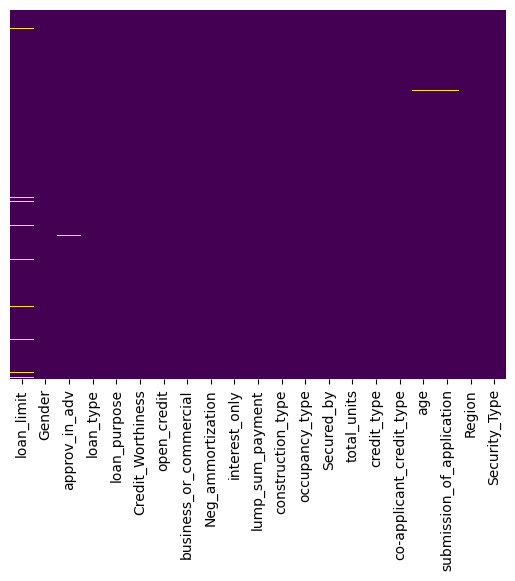

In [14]:
sns.heatmap(df[object_column].isnull(),yticklabels = False, cbar = False, cmap = 'viridis')

## Observation:
- Missing values in Age and Submission_of_application columns are not random. If they are random, then there would be 0's as well in the status corresponding to the missing row. Hence, this is not MCAR.
- Submission_of_application and age column's missing values are also not related to other columns as well. Hence it is not MAR.
- Age and Submission_of_application fields missing are related to the Status column. These indicates anyone of them:
    - Defaulted borrowers were approved through a faster/informal channel that skipped these fields.
    - These fields were deliberately not collected for a specific high-risk loan product.
    - Borrowers who eventually defaulted were less cooperative in providing information upfront.
- Missingness encodes the borrower's risk profile. This could be MNAR.
- Missing % of Approv_in_adv, age, and Submission_of_application, loan_purpose and Neg_ammortization is less than 1 %. Hence, Statistical imputation or domain knowledge based imputation would be appropriate.
- Loan_limit missing % is greater than 2 %. Hence missing and non-missing relation is further checked with the Status column. Since the difference is 1.74%, missing rows behave similarly to non-missing rows. It points towards MCAR.

## Step 4: Duplicate Row Check

In [15]:
n = df.duplicated().sum()
print(f"Number of Duplicated row in the dataset is {n}.")

Number of Duplicated row in the dataset is 0.


## Step 5: Target Column Distribution

In [16]:
#Target distribution analysis
#Counts and proportion

def target_distribution(df, target_col):
    print(f"=== Target Distribution: {target_col} column ===\n")
    print(df[target_col].value_counts())
    print()
    print(df[target_col].value_counts(normalize=True).round(3) * 100)

    majority = df[target_col].value_counts(normalize=True).max()
    minority  = df[target_col].value_counts(normalize=True).min()
    ratio     = round(majority / minority, 1)

    print(f"\nImbalance ratio: {ratio}:1")

    if 1 <= ratio < 1.5:
        situation = "Balanced"
        metric    = "Accuracy is fine"
        action    = "No special handling needed"
    elif 1.5 <= ratio < 4:
        situation = "Mild imbalance"
        metric    = "F1 + AUC-ROC"
        action    = "Add class_weight='balanced' to model"
    elif 4 <= ratio < 9:
        situation = "Moderate imbalance"
        metric    = "AUC-ROC + F1"
        action    = "class_weight='balanced' + evaluate SMOTE"
    elif 9 <= ratio < 99:
        situation = "Severe imbalance"
        metric    = "Precision-Recall AUC"
        action    = "SMOTE or undersampling mandatory"
    else:
        situation = "Extreme imbalance"
        metric    = "Precision-Recall AUC"
        action    = "Consider anomaly detection approach"

    print(f"Situation      : {situation}")
    print(f"Metric         : {metric}")
    print(f"Pipeline action: {action}")


target_distribution(df, 'Status')

=== Target Distribution: Status column ===

Status
0    112031
1     36639
Name: count, dtype: int64

Status
0    75.4
1    24.6
Name: proportion, dtype: float64

Imbalance ratio: 3.1:1
Situation      : Mild imbalance
Metric         : F1 + AUC-ROC
Pipeline action: Add class_weight='balanced' to model


## Step 6: Numerical feature distribution

array([[<Axes: title={'center': 'ID'}>, <Axes: title={'center': 'year'}>,
        <Axes: title={'center': 'loan_amount'}>,
        <Axes: title={'center': 'rate_of_interest'}>],
       [<Axes: title={'center': 'Interest_rate_spread'}>,
        <Axes: title={'center': 'Upfront_charges'}>,
        <Axes: title={'center': 'term'}>,
        <Axes: title={'center': 'property_value'}>],
       [<Axes: title={'center': 'income'}>,
        <Axes: title={'center': 'Credit_Score'}>,
        <Axes: title={'center': 'LTV'}>,
        <Axes: title={'center': 'Status'}>],
       [<Axes: title={'center': 'dtir1'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

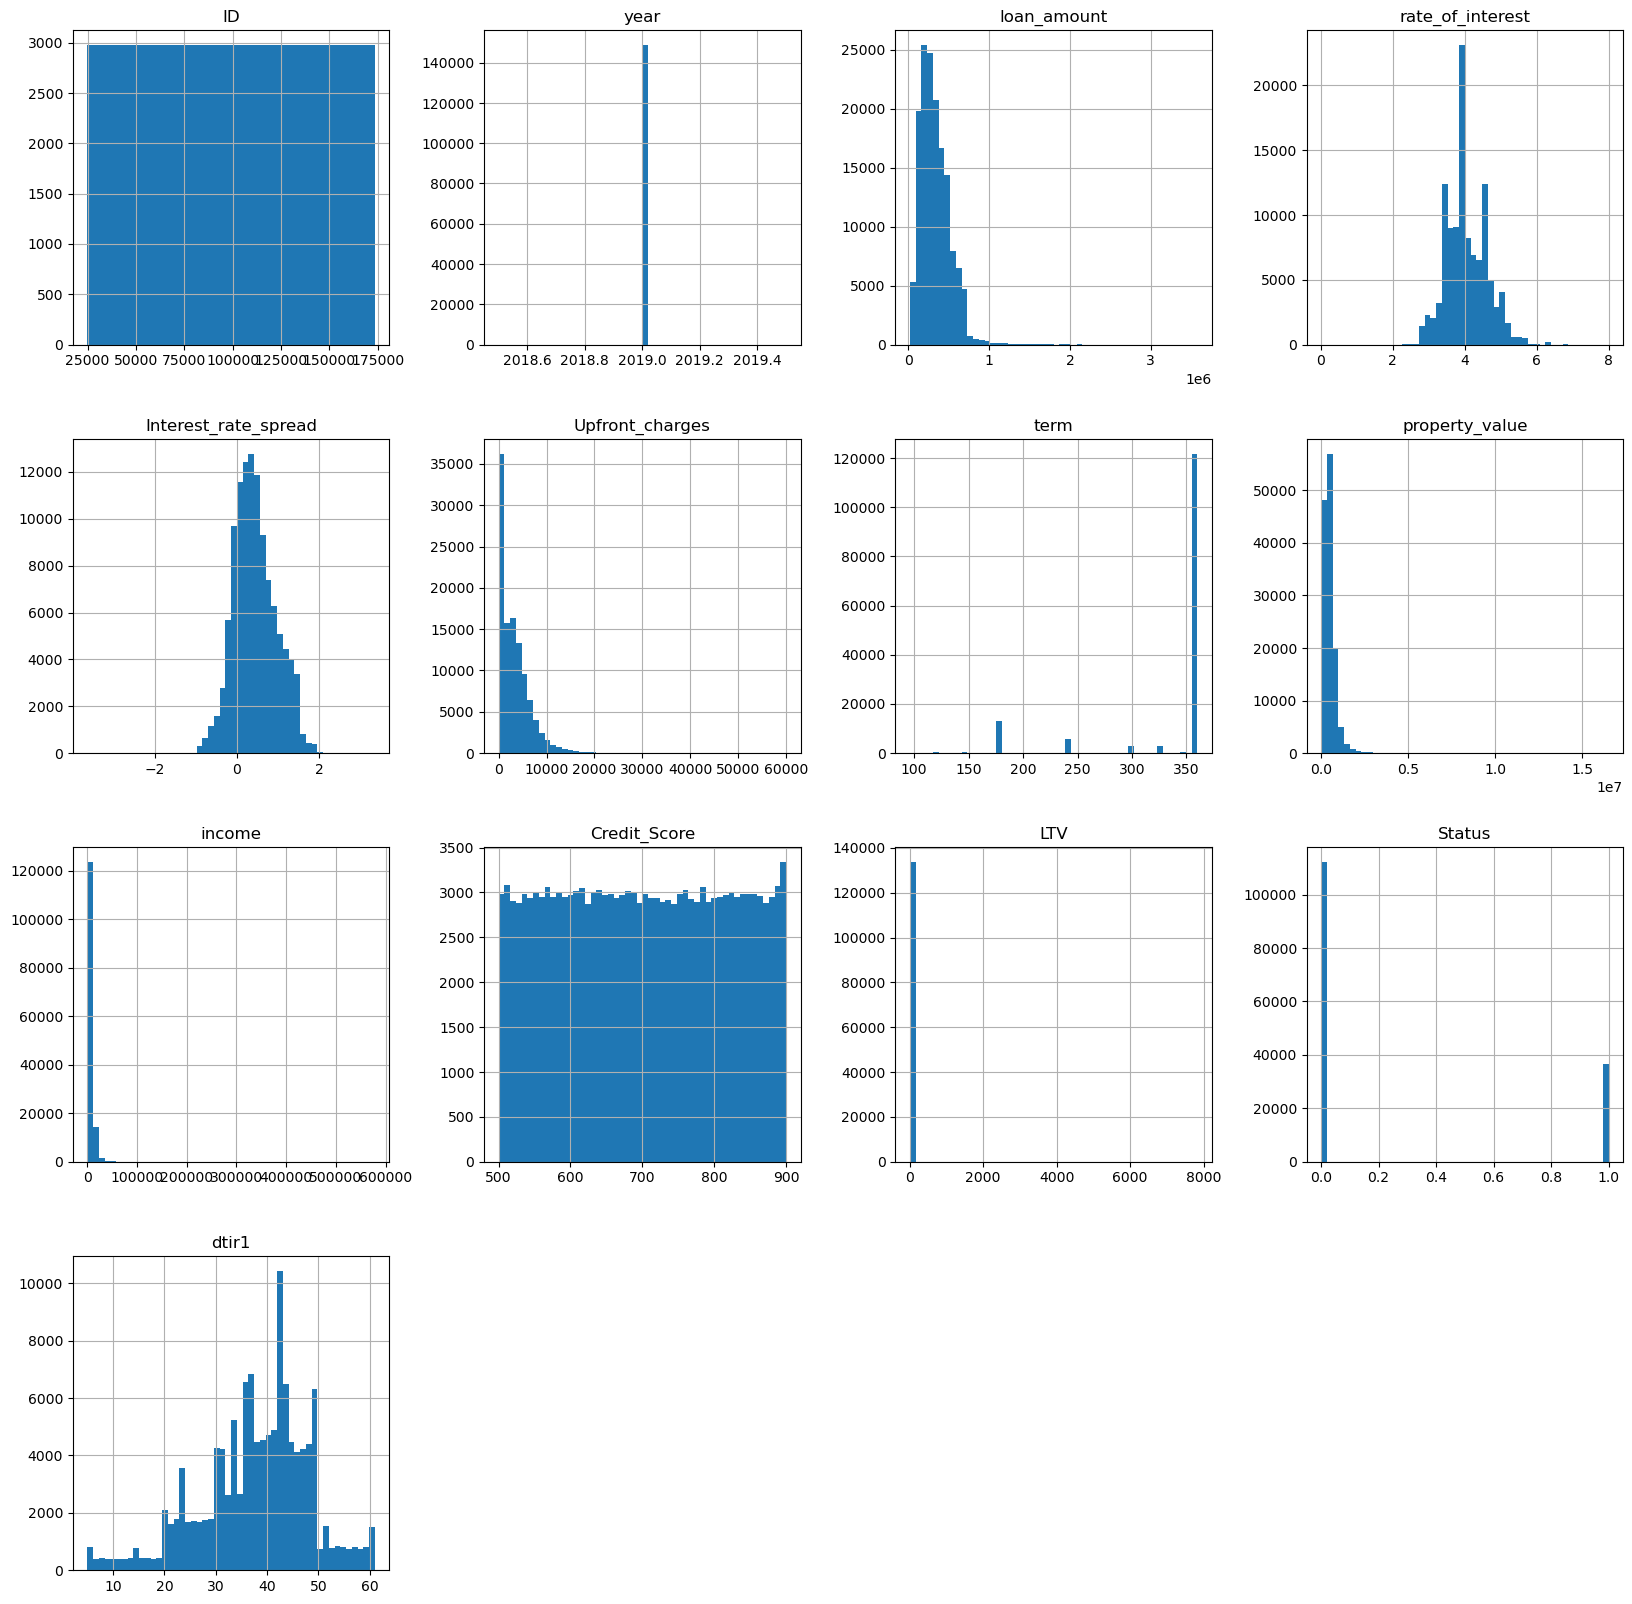

In [17]:
df.hist(bins=50, figsize=(20,20))

In [18]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


## Step 7: Skewness & Kurtosis measurement

In [19]:
num_cols = df.select_dtypes(include=['number']).columns

skew_kurt_df = pd.DataFrame({
                    'skewness':df[num_cols].skew(),
                    'Kurtosis':df[num_cols].kurt(),
}).sort_values('skewness', key = abs, ascending = False)

high_skew = skew_kurt_df[skew_kurt_df['skewness'].abs() > 1].index.tolist()
mod_skew = skew_kurt_df[(skew_kurt_df['skewness'].abs() > 0.5) & (skew_kurt_df['skewness'].abs() < 1)].index.tolist()
high_kurt = skew_kurt_df[skew_kurt_df['Kurtosis'].abs() > 1].index.tolist()

print("High Skew (need transformation):", high_skew)
print("Moderate Skew (monitor):", mod_skew)
print("High Kurt:", high_kurt)

High Skew (need transformation): ['LTV', 'income', 'property_value', 'term', 'Upfront_charges', 'loan_amount', 'Status']
Moderate Skew (monitor): ['dtir1']
High Kurt: ['LTV', 'income', 'property_value', 'term', 'Upfront_charges', 'loan_amount', 'Credit_Score', 'ID']


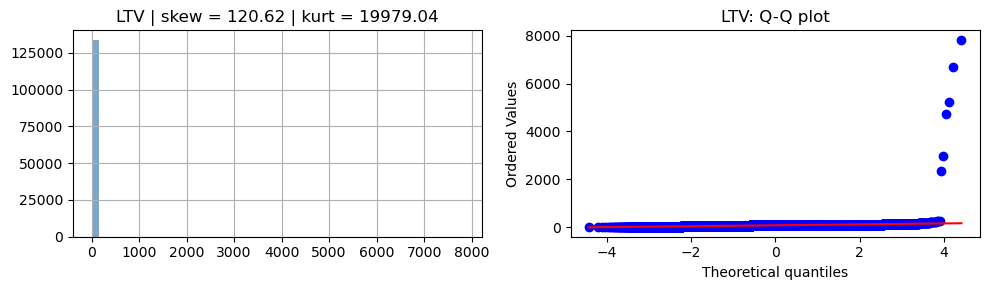

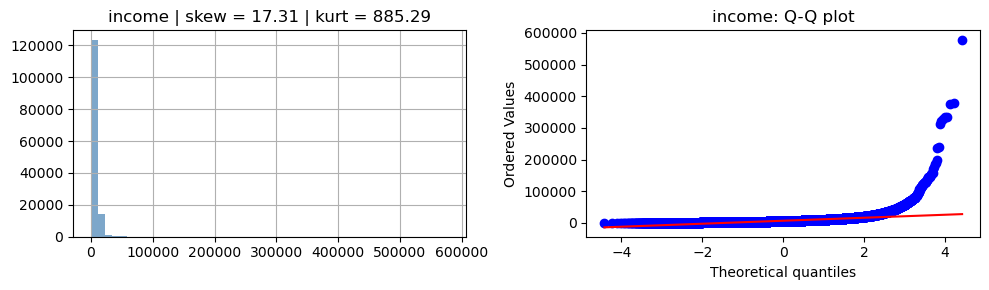

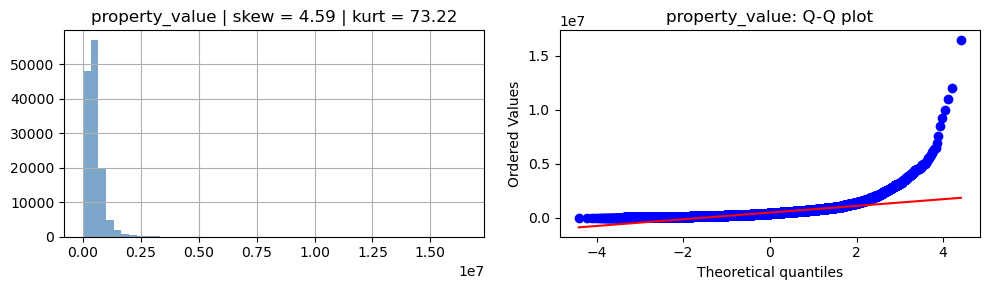

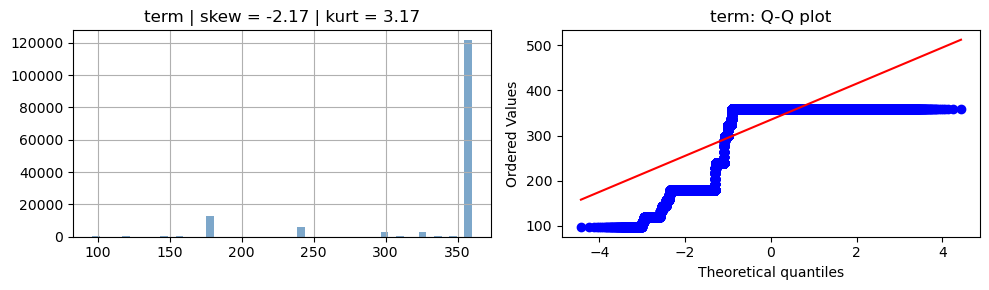

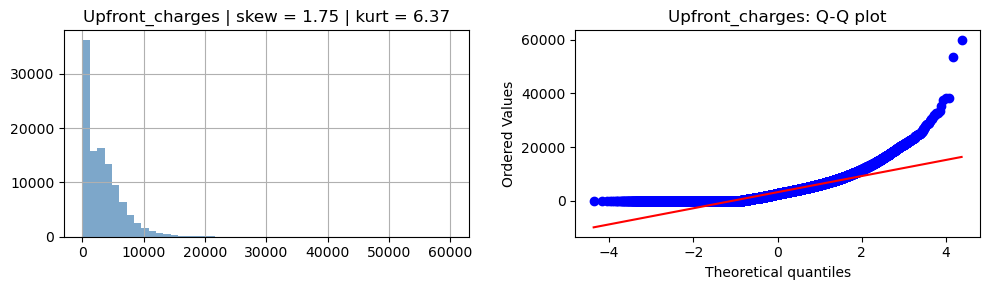

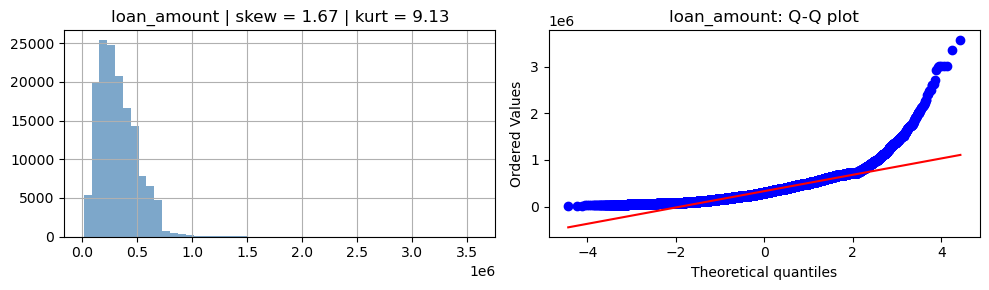

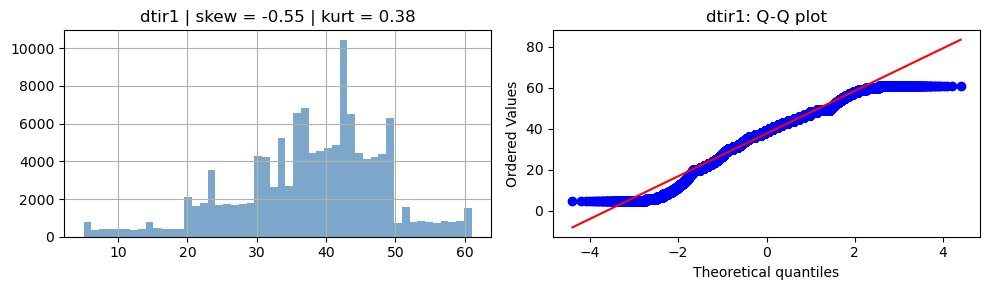

In [20]:
# Q-Q plot
cols_to_plot = [col for col in high_skew + mod_skew if col != 'Status']

for col in cols_to_plot:
    fig, axes = plt.subplots(1,2,figsize=(10,3))

    #Histogram with KDE
    df[col].hist(ax= axes[0], bins=50, alpha= 0.7, edgecolor=None, color= 'steelblue')
    axes[0].set_title(f'{col} | skew = {df[col].skew():.2f} | kurt = {df[col].kurt():.2f}')

    #Q-Q Plot 
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f"{col}: Q-Q plot")

    plt.tight_layout()
    plt.show()

## Observation:
 - Extremely high skew value indicates LTV data could have large number of erroneous data. There is certainly data quality issue.
   This column needs range validation. LTV above 200% should be inspected.
 - High Kurt value = 73.22 indicates exceptionally high property value. These high value properties are financing disproportionately high loans. These accounts will be at highest risk and highest value simultaneously. Mandatory log1p or Yeo-Johnson transform. Also flag top 1% for outlier investigation.
 - Income histogram is extremely right skewed. Extremely High Kurt value suggest, either few individuals have extremely high income or their could be discrepancy in recording the income. (Ex: Annual income recorded as monthly income). This column requires individual outlier row inspection.
 - Loan amount is right skewed. High kurt value (9.13) and Q-Q curve shoots sharply upward suggest extreme high loan amounts occur far more often than normal loan amount distribution. log1p or Yeo-Johnson transform required.
 - Bounded right skewed histogram of upfront charges is similar to loan amount, with spike near zero and long tail. log1p transform required (check for zeros first).

## Pipeline Tranformation Decision
- income'         : 'log1p — extreme right skew (17.31)',
- 'property_value' : 'log1p — severe right skew (4.59)',
- 'loan_amount'    : 'log1p — right skew (1.67)',
- 'Upfront_charges': 'log1p — right skew (1.75)',
- 'LTV'            : 'fix data quality first, then reassess',
- 'term'           : 'Yeo-Johnson — left skew (-2.17)',
- 'dtir1'          : 'none — near normal (-0.55)',
- 'rate_of_interest': 'none — near normal (0.39)',
- 'Credit_Score'   : 'none — symmetric (0.00)',

## Step 8: Outlier Detection 

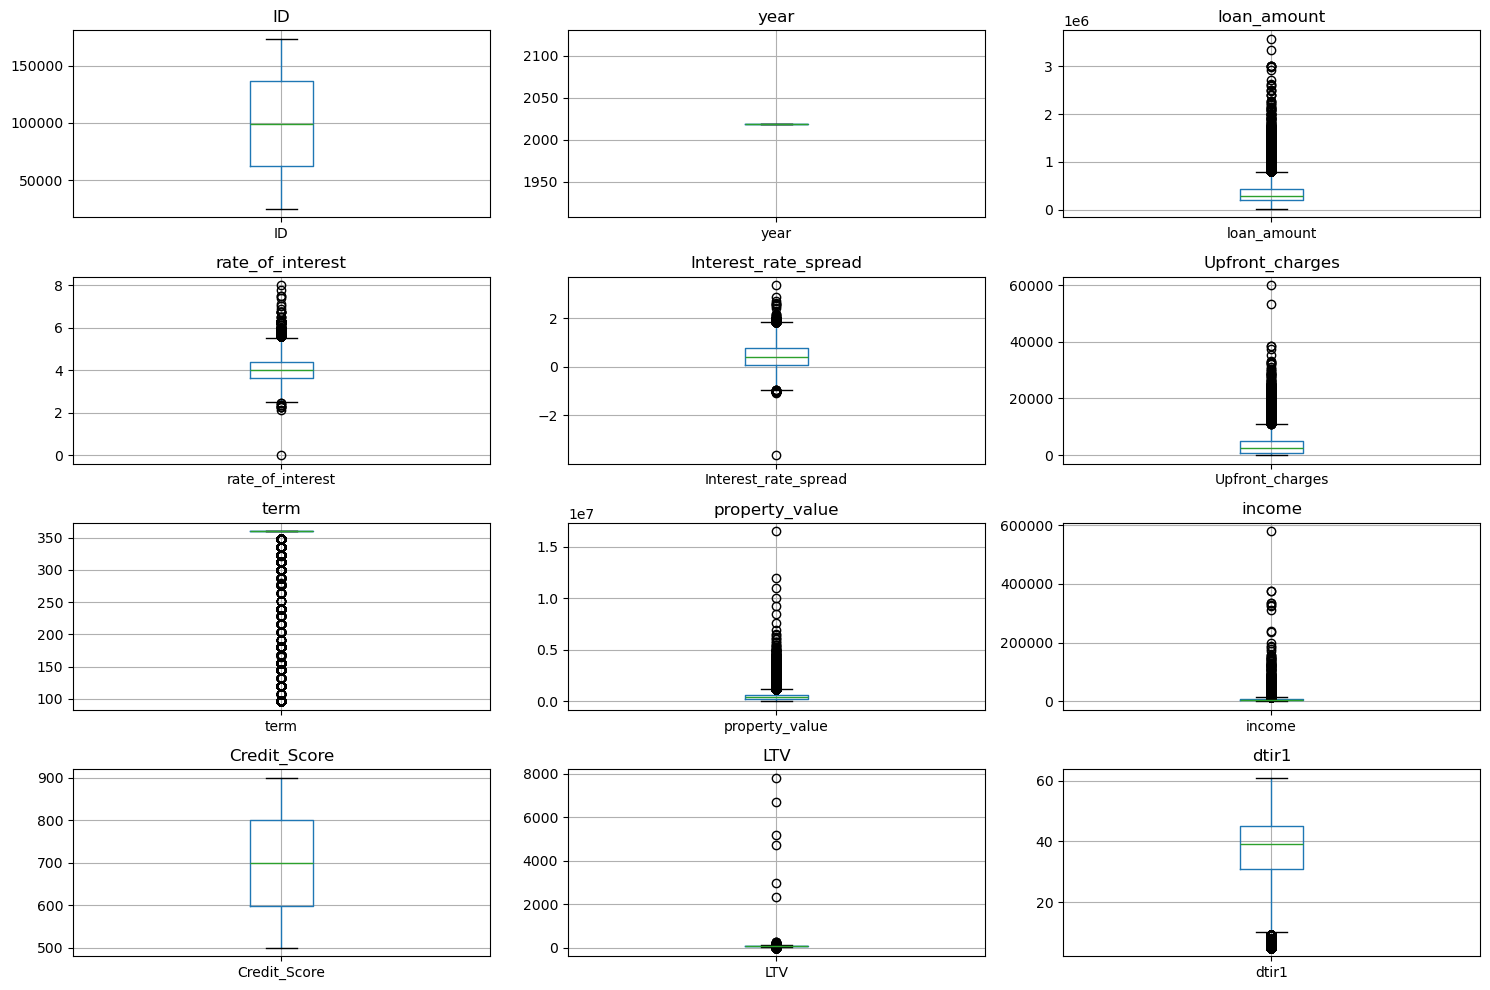

In [21]:
columns = [col for col in num_column if col != 'Status']
plt_col = 3
plt_row = (len(columns) + plt_col - 1) // plt_col
fig, axes = plt.subplots(plt_row,plt_col,figsize = (15,10))
axes = axes.flatten()

for i, feature in enumerate(columns):
    df.boxplot(column = feature, ax = axes[i])
    axes[i].set_title(f'{feature}')

plt.tight_layout()
plt.show()

In [22]:
## Counting number of outliers in all numerical columns
num_cols = df.select_dtypes(include = ['number']).columns.tolist()

record = {}

col = 'income'
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_whisker = Q3 + 1.5*IQR
    lower_whisker = Q1 - 1.5*IQR

    total_valid = df[col].notna().sum()   # Exclude NaN from column count
    lout_cnt = (df[col] < lower_whisker).sum()
    uout_cnt = (df[col] > upper_whisker).sum()
    total_cnt = lout_cnt + uout_cnt

    if lout_cnt > 0 and uout_cnt == 0:
        direction = 'Lower only'
    elif lout_cnt == 0 and uout_cnt > 0:
        direction = 'Upper only'
    elif lout_cnt > 0 and uout_cnt > 0:
        direction = 'Both sides'
    else:
        direction = 'None'

    record[col] = {
        'lower_outliers' : lout_cnt,
        'upper_outliers' : uout_cnt,
        'Total_outliers' : total_cnt,
        'Outlier %' : round((total_cnt/total_valid)*100,2),
        'Direction' : direction,
        'IQR' : IQR == 0
    }
    

df_record = pd.DataFrame(record)
df_record

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
lower_outliers,0,0,0,10,31,0,26944,0,0,0,1762,0,2013
upper_outliers,0,0,1895,846,414,2880,0,5266,6546,0,120,36639,0
Total_outliers,0,0,1895,856,445,2880,26944,5266,6546,0,1882,36639,2013
Outlier %,0.0,0.0,1.27,0.76,0.4,2.64,18.13,3.94,4.69,0.0,1.41,24.64,1.62
Direction,None,None,Upper only,Both sides,Both sides,Upper only,Lower only,Upper only,Upper only,None,Both sides,Upper only,Lower only
IQR,False,True,False,False,False,False,True,False,False,False,False,True,False


In [23]:
df[df['LTV'] > 200]['LTV']

3578       201.315789
16951     7831.250000
27473      237.500000
30837      237.500000
36502      200.641026
40617      201.041667
43348      263.541667
46287     2956.250000
47807     5206.250000
51248      201.785714
55286     6706.250000
65238     4706.250000
98854      201.315789
114663     200.568182
123343    2331.250000
136154     220.362903
137293     201.315789
Name: LTV, dtype: float64

In [24]:
# Total Default % of Dataset

default_loan_pct = round((df.loc[df['Status'] == 1, 'Status'].sum()/df['Status'].notna().sum())*100,2)
default_loan_pct

np.float64(24.64)

In [25]:
Q3 = df['loan_amount'].quantile(0.75)
Q1 = df['loan_amount'].quantile(0.25)
IQR = Q3 - Q1
upper_whisker_l = Q3 + 1.5*IQR

status_loan_amt = df.loc[df['loan_amount'] > upper_whisker_l,'Status'].value_counts()
pct_default_loan = round(status_loan_amt.get(1,0)/status_loan_amt.sum()*100, 2)
pct_not_default_loan = round(status_loan_amt.get(0,0)/status_loan_amt.sum()*100, 2)

print(f"{pct_default_loan} % of outlier loan amounts (above {upper_whisker_l}) are defaulted.")
print(f"{pct_not_default_loan} % of outlier loan amounts (above {upper_whisker_l}) are not defaulted.")


44.8 % of outlier loan amounts (above 796500.0) are defaulted.
55.2 % of outlier loan amounts (above 796500.0) are not defaulted.


In [26]:
Q3 = df['income'].quantile(0.75)
Q1 = df['income'].quantile(0.25)
IQR = Q3 - Q1
upper_whisker_i = Q3 + 1.5*IQR

status = df.loc[df['income'] > upper_whisker_i, 'Status'].value_counts()
pct_loan_def = round(status.get(1,0)/status.sum() * 100,2)
pct_loan_clr = round(status.get(0,0)/status.sum() * 100,2)

print(f"{pct_loan_def}% of outlier loans (income > {upper_whisker_i}) are defaulted.")
print(f"{pct_loan_clr}% of outlier loans (income > {upper_whisker_i}) are not defaulted.")

print(f"High income does not appear to protect against default — outlier income borrowers default at {pct_loan_def}%, nearly identical to the overall rate of {default_loan_pct}%.")

23.02% of outlier loans (income > 15720.0) are defaulted.
76.98% of outlier loans (income > 15720.0) are not defaulted.
High income does not appear to protect against default — outlier income borrowers default at 23.02%, nearly identical to the overall rate of 24.64%.


In [27]:
Q3 = df['rate_of_interest'].quantile(0.75)
Q1 = df['rate_of_interest'].quantile(0.25)
IQR = Q3 - Q1
upper_whisker_r = Q3 + 1.5*IQR

interest_rate = df.loc[df['rate_of_interest'] > upper_whisker_r, 'Status'].value_counts()
pct_default_ir = round((interest_rate.get(1,0)/interest_rate.sum())*100,2)
pct_not_default_ir = round((interest_rate.get(0)/interest_rate.sum())*100,2)

print(f"{pct_default_ir} % of defaulted loans are of high (outliers) rate of interest ({upper_whisker_r}).")

0.0 % of defaulted loans are of high (outliers) rate of interest (5.5).


In [28]:
upper_whisker_r

np.float64(5.5)

In [29]:
# 0 % default rate for high interest rate create suspicion as it is counterintuitive to have no default for high interest rate.
df.loc[(df['rate_of_interest'] > upper_whisker_r) & (df['Status'] == 1), ['loan_type','loan_purpose','loan_amount','Status']]

,loan_type,loan_purpose,loan_amount,Status


In [30]:
# Check credit scores and income of high interest rate borrowers
high_ir = df.loc[df['rate_of_interest'] > upper_whisker_r]
normal  = df.loc[df['rate_of_interest'] <= upper_whisker_r]

print("Credit Score comparison:")
print(f"  High IR loans : {high_ir['Credit_Score'].mean():.1f}")
print(f"  Normal loans  : {normal['Credit_Score'].mean():.1f}")

print("\nIncome comparison:")
print(f"  High IR loans : {high_ir['income'].median():.1f}")
print(f"  Normal loans  : {normal['income'].median():.1f}")

print("\nLoan amount comparison:")
print(f"  High IR loans : {high_ir['loan_amount'].median():.1f}")
print(f"  Normal loans  : {normal['loan_amount'].median():.1f}")

print("\nTerm comparison:")
print(f"  High IR loans : {high_ir['term'].median():.1f}")
print(f"  Normal loans  : {normal['term'].median():.1f}")

print("\n loan_type comparison:")
print(f"  High IR loans : {high_ir['loan_type'].mode()[0]}")
print(f"  Normal loans  : {normal['loan_type'].mode()[0]}")

print("\n credit_type comparison:")
print(f"  High IR loans : {high_ir['credit_type'].mode()[0]}")
print(f"  Normal loans  : {normal['credit_type'].mode()[0]}")

Credit Score comparison:
  High IR loans : 703.0
  Normal loans  : 699.5

Income comparison:
  High IR loans : 7110.0
  Normal loans  : 6000.0

Loan amount comparison:
  High IR loans : 186500.0
  Normal loans  : 306500.0

Term comparison:
  High IR loans : 360.0
  Normal loans  : 360.0

 loan_type comparison:
  High IR loans : type1
  Normal loans  : type1

 credit_type comparison:
  High IR loans : CIB
  Normal loans  : CIB


### Observation:
#### Loans with interest rates above 5.5% (846 rows) show zero record results. Borrower profile analysis shows, these are not high-risk borrower - median credit score (703) and income (7110.0) are slightly better than normal borrowers. However, their median loan amount (186500.0) is significantly lower than normal loan amount (306500.0). This suggests high-IR loans represent a distinct loan product segment rather than high-risk borrowers. The zero default rate likely reflects either a genuinely low-risk product structure

In [31]:
Q3 = df['Upfront_charges'].quantile(0.75)
Q1 = df['Upfront_charges'].quantile(0.25)
IQR = Q3 - Q1
upper_whisker_u = Q3 + 1.5*IQR

mean_uc_charges = round(df.loc[df['Upfront_charges'] < upper_whisker_u, 'Upfront_charges'].mean(),2)

status_uc_cnt = df.loc[df['Upfront_charges'] > upper_whisker_u,'Status'].value_counts()
pct_default = round(status_uc_cnt.get(1,0)/status_uc_cnt.sum()*100, 2)
pct_not_default = round(status_uc_cnt.get(0,0)/status_uc_cnt.sum()*100, 2)

print(f"{pct_default} % of loans get defaulted having very high upfront charges (greater than {upper_whisker_u}, mean = {mean_uc_charges}).")

0.07 % of loans get defaulted having very high upfront charges (greater than 11159.015, mean = 2920.02).


In [32]:
# 0 % default rate for high interest rate create suspicion as it is counterintuitive to have no default for high interest rate.
df.loc[(df['Upfront_charges'] > upper_whisker_r) & (df['Status'] == 1), ['loan_type','loan_purpose','loan_amount','Status']]

,loan_type,loan_purpose,loan_amount,Status
706,type1,p1,126500,1
1219,type2,p3,346500,1
3533,type2,p3,146500,1
4029,type2,p1,56500,1
5011,type2,p1,106500,1
...,...,...,...,...
141025,type2,p1,156500,1
141110,type1,p1,206500,1
145071,type2,p3,156500,1
147037,type1,p3,446500,1


In [33]:
# Check credit scores and income of high interest rate borrowers
high_uc = df.loc[df['Upfront_charges'] > upper_whisker_u]
normal_uc  = df.loc[df['Upfront_charges'] <= upper_whisker_u]

print("Credit Score comparison:")
print(f"  High UC loans : {high_uc['Credit_Score'].mean():.1f}")
print(f"  Normal loans  : {normal_uc['Credit_Score'].mean():.1f}")

print("\nIncome comparison:")
print(f"  High UC loans : {high_uc['income'].median():.1f}")
print(f"  Normal loans  : {normal_uc['income'].median():.1f}")

print("\nLoan amount comparison:")
print(f"  High UC loans : {high_uc['loan_amount'].median():.1f}")
print(f"  Normal loans  : {normal_uc['loan_amount'].median():.1f}")

print("\nTerm comparison:")
print(f"  High UC loans : {high_uc['term'].median():.1f}")
print(f"  Normal loans  : {normal_uc['term'].median():.1f}")

print("\n loan_type comparison:")
print(f"  High UC loans : {high_uc['loan_type'].mode()[0]}")
print(f"  Normal loans  : {normal_uc['loan_type'].mode()[0]}")

print("\n credit_type comparison:")
print(f"  High UC loans : {high_uc['credit_type'].mode()[0]}")
print(f"  Normal loans  : {normal_uc['credit_type'].mode()[0]}")

Credit Score comparison:
  High UC loans : 701.6
  Normal loans  : 699.4

Income comparison:
  High UC loans : 8340.0
  Normal loans  : 5940.0

Loan amount comparison:
  High UC loans : 506500.0
  Normal loans  : 306500.0

Term comparison:
  High UC loans : 360.0
  Normal loans  : 360.0

 loan_type comparison:
  High UC loans : type1
  Normal loans  : type1

 credit_type comparison:
  High UC loans : CIB
  Normal loans  : CIB


## Observation:
 - Most of the outliers in LTV data are on lower end.
 - loan amount data have many outliers in the higher end.
 - Some of the loans are given at very high rate of interest than the average.
 - Upfront charges are also very high (Outliers) for some sanctioned loans. Larger loans attract higher processing fees.
 - debt to income ratio has outliers on the side of lower whiskers. 

## Step 9: Categorical feature analysis (Cardinality, frequency, rare labels)

In [34]:
# Basic profile for each column
analysis = {}

for col in object_column:
    analysis[col] = {
        "Name" : col,
        "Unique count" : df[col].nunique(),
        "Unique values" : df[col].unique().tolist(),
        "Missing count" : df[col].isnull().sum(),
        "Missing %" : round(df[col].isnull().sum()/len(df)*100, 2)
    }

result = pd.DataFrame(analysis)
result

,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,...,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
Name,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,Neg_ammortization,interest_only,...,construction_type,occupancy_type,Secured_by,total_units,credit_type,co-applicant_credit_type,age,submission_of_application,Region,Security_Type
Unique count,2,4,2,3,4,2,2,2,2,2,...,2,3,2,4,4,2,7,2,4,2
Unique values,"[cf, nan, ncf]","[Sex Not Available, Male, Joint, Female]","[nopre, pre, nan]","[type1, type2, type3]","[p1, p4, p3, p2, nan]","[l1, l2]","[nopc, opc]","[nob/c, b/c]","[not_neg, neg_amm, nan]","[not_int, int_only]",...,"[sb, mh]","[pr, sr, ir]","[home, land]","[1U, 2U, 3U, 4U]","[EXP, EQUI, CRIF, CIB]","[CIB, EXP]","[25-34, 55-64, 35-44, 45-54, 65-74, >74, <25, ...","[to_inst, not_inst, nan]","[south, North, central, North-East]","[direct, Indriect]"
Missing count,3344,0,908,0,134,0,0,0,121,0,...,0,0,0,0,0,0,200,200,0,0
Missing %,2.25,0.0,0.61,0.0,0.09,0.0,0.0,0.0,0.08,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.13,0.13,0.0,0.0


In [35]:
#Checking column with high cardinality
result = []

for col in object_column:
    n_unique = df[col].nunique()
    if n_unique > 10:
        result.append(col)

if len(result):
    print(f" These are the columns with high cardinality")
    print(result)
else:
    print(f" There is no column with high cardinality.")

 There is no column with high cardinality.


#### Here no object column has high cardinality. Hence, Hot-end encoding could be used in preprocessing step.

In [36]:
#Frequency Distribution

for col in object_column:
    print(f"\n{col}")
    freq = pd.DataFrame({
        'Count' : df[col].value_counts(dropna = False),
        'Freq_%' : round((df[col].value_counts(dropna = False)/len(df)*100),2)
    })
    print(freq)


loan_limit
             Count  Freq_%
loan_limit                
cf          135348   91.04
ncf           9978    6.71
NaN           3344    2.25

Gender
                   Count  Freq_%
Gender                          
Male               42346   28.48
Joint              41399   27.85
Sex Not Available  37659   25.33
Female             27266   18.34

approv_in_adv
                Count  Freq_%
approv_in_adv                
nopre          124621   83.82
pre             23141   15.57
NaN               908    0.61

loan_type
            Count  Freq_%
loan_type                
type1      113173   76.12
type2       20762   13.97
type3       14735    9.91

loan_purpose
              Count  Freq_%
loan_purpose               
p3            55934   37.62
p4            54799   36.86
p1            34529   23.23
p2             3274    2.20
NaN             134    0.09

Credit_Worthiness
                    Count  Freq_%
Credit_Worthiness                
l1                 142344   95.74
l2        

### Observation: 
 - Missing rows are present in all these columns: Loan_limit, approv_in_advance, Loan purpose, Neg_ammortization, age and Submission_of_application.
 - These are the columns with particular category having frequency less than 1%:
   - open credit: opc has 0.37% frequency.
    - Construction_type: mh has 0.02 % frequency.
    - Secured_by: land has 0.02 % frequency.
    - total_units: 2U, 3U & 4U have 0.99, 0.26 and 0.22 % frequency respectively.
    - Age: <25 has 0.90% frequency.
    - Region: North-East has 0.83% frequency.
    - Security_Type: Indirect has 0.02% frequency.


## Tranformation Strategy in Pipeline
- 

In [37]:
## Data Quality check
## Unique terms within each column. This step is done to check misspelling
for col in object_column:
    print(f"\n{col} : {df[col].unique().tolist()}")

#Look for:
#Issue                            Example from your dataset           Pipeline fix
#Spelling errors               'Indriect' instead of 'Indirect'    Fix before encoding
#Inconsistent casing           'south' vs 'North' in Region        Lowercase all values 
#Inconsistent spacing          'type1' vs 'type1 'Strip whitespace
#Same meaning, different label 'nob/c' and 'b/c' unclear           Clarify with domain knowledge
#Ordinal disguised as nominal   age column in your dataset         Use ordinal encoding not OHE



loan_limit : ['cf', nan, 'ncf']

Gender : ['Sex Not Available', 'Male', 'Joint', 'Female']

approv_in_adv : ['nopre', 'pre', nan]

loan_type : ['type1', 'type2', 'type3']

loan_purpose : ['p1', 'p4', 'p3', 'p2', nan]

Credit_Worthiness : ['l1', 'l2']

open_credit : ['nopc', 'opc']

business_or_commercial : ['nob/c', 'b/c']

Neg_ammortization : ['not_neg', 'neg_amm', nan]

interest_only : ['not_int', 'int_only']

lump_sum_payment : ['not_lpsm', 'lpsm']

construction_type : ['sb', 'mh']

occupancy_type : ['pr', 'sr', 'ir']

Secured_by : ['home', 'land']

total_units : ['1U', '2U', '3U', '4U']

credit_type : ['EXP', 'EQUI', 'CRIF', 'CIB']

co-applicant_credit_type : ['CIB', 'EXP']

age : ['25-34', '55-64', '35-44', '45-54', '65-74', '>74', '<25', nan]

submission_of_application : ['to_inst', 'not_inst', nan]

Region : ['south', 'North', 'central', 'North-East']

Security_Type : ['direct', 'Indriect']


## Observation:
- There is no spelling error.
- Inconsistent casing is found for Region and Security_type category.
- No inconsistent spacing.
- Here age column is not in increasing order, that is it is nominal now. Ordinal encoding needs to be done during pipeline preprocessing.

In [38]:
# Listing default % with respect to category in each column

for col in object_column:
    print(f"\n{col}")
    result = pd.DataFrame({
        'count'          : df[col].value_counts(dropna=False),
        'freq_%'         : (df[col].value_counts(dropna=False)/len(df)*100).round(2),
        'default_rate_%' : (df.groupby(col, dropna=False)['Status'].mean()*100).round(2)
    })
    print(result.sort_values('default_rate_%', ascending=False))


loan_limit
             count  freq_%  default_rate_%
loan_limit                                
ncf           9978    6.71           33.21
NaN           3344    2.25           26.35
cf          135348   91.04           23.97

Gender
                   count  freq_%  default_rate_%
Gender                                          
Sex Not Available  37659   25.33           28.59
Male               42346   28.48           26.19
Female             27266   18.34           25.12
Joint              41399   27.85           19.16

approv_in_adv
                count  freq_%  default_rate_%
approv_in_adv                                
NaN               908    0.61           26.54
nopre          124621   83.82           25.33
pre             23141   15.57           20.89

loan_type
            count  freq_%  default_rate_%
loan_type                                
type2       20762   13.97           34.54
type3       14735    9.91           25.06
type1      113173   76.12           22.77

loan

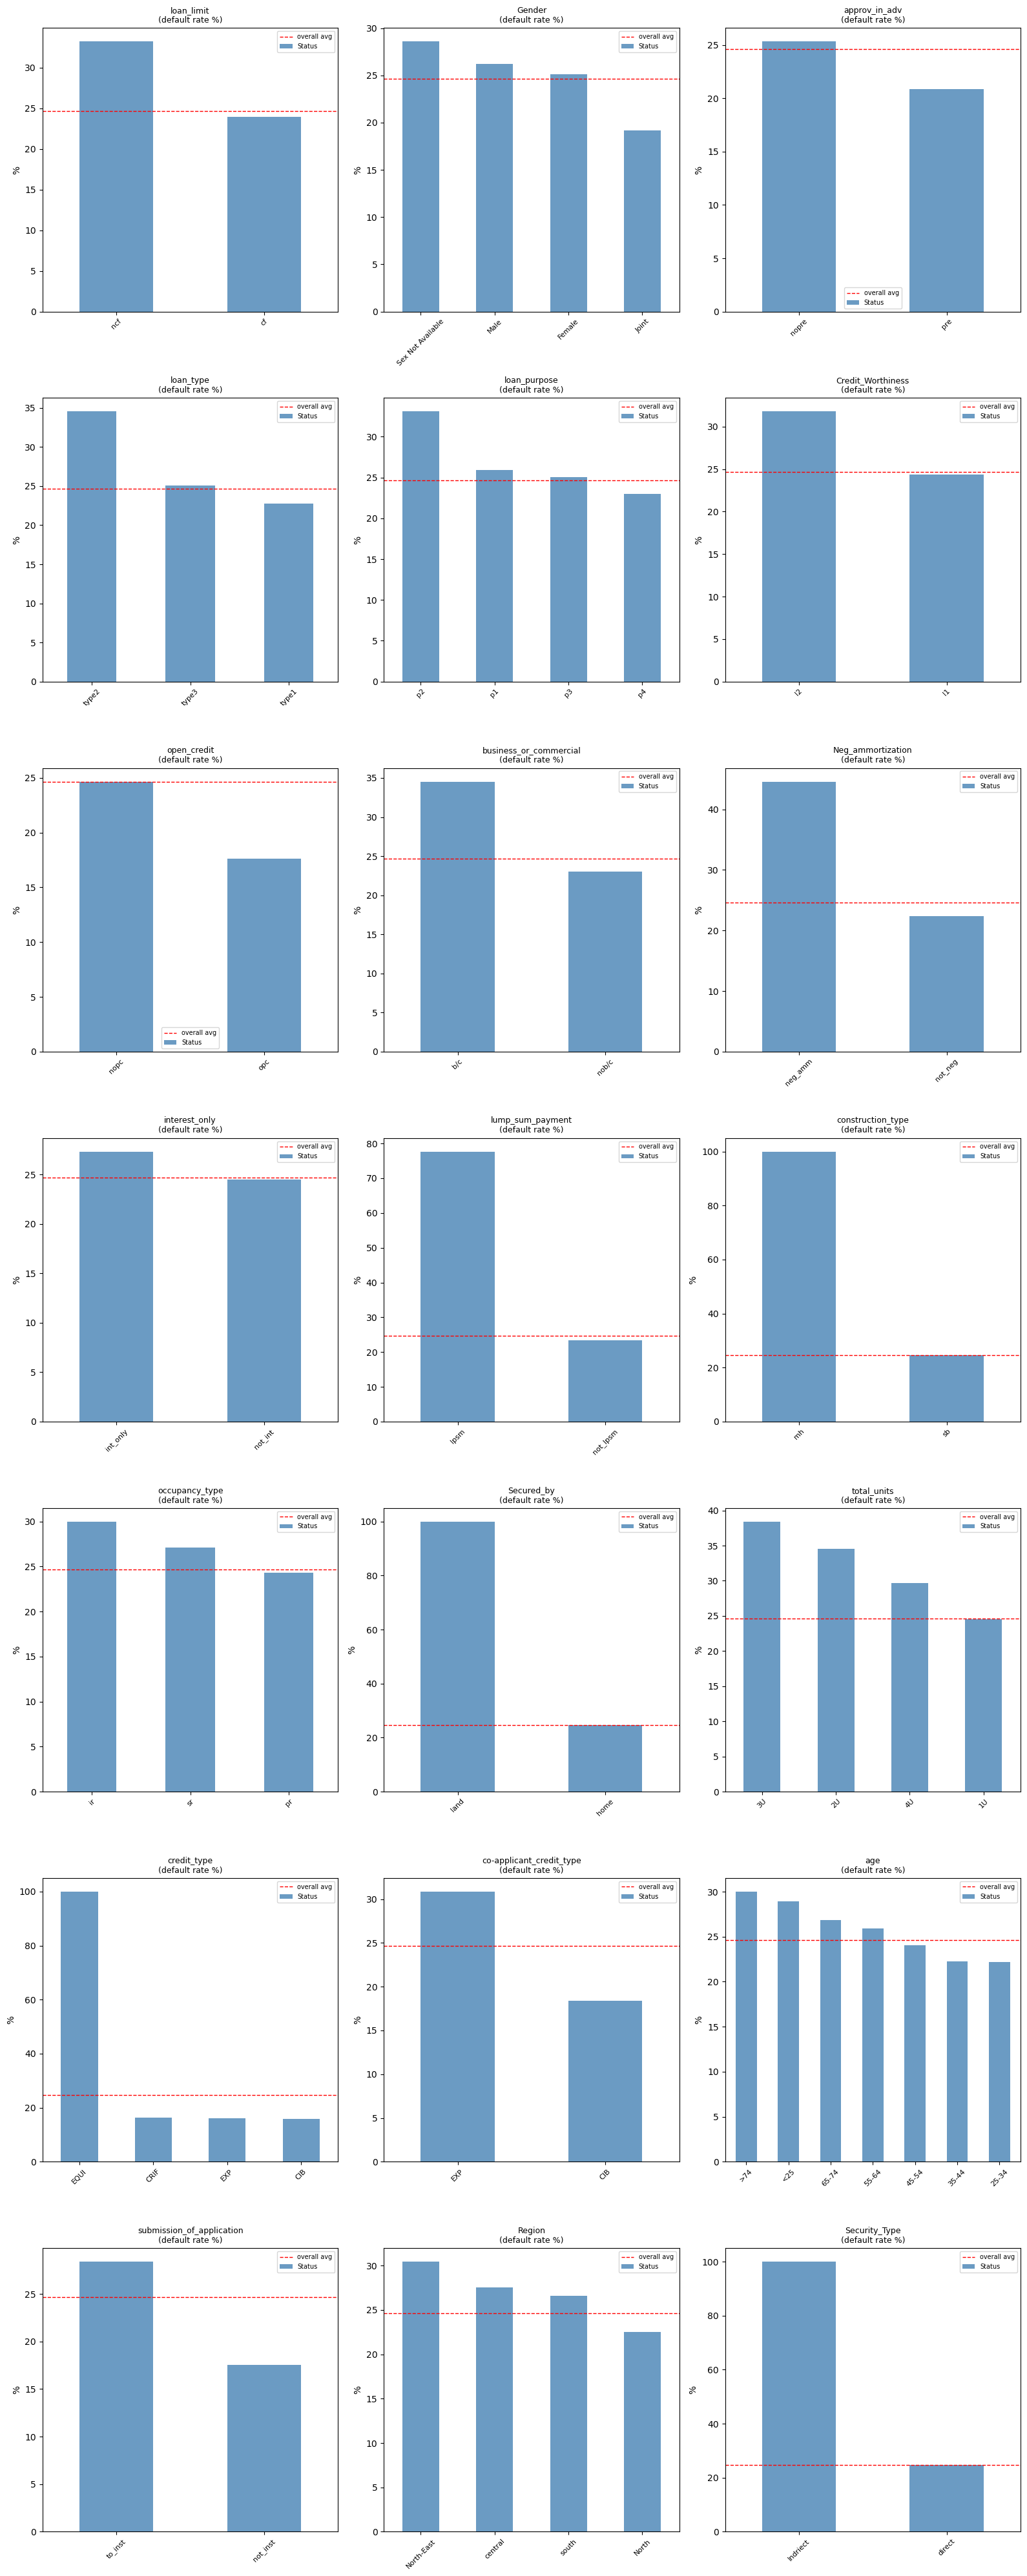

In [39]:
# Visualizing default rate per category for each object column

fig, axes = plt.subplots((len(object_column) + 3 - 1)//3 , 3, figsize=(16, 40))
axes = axes.flatten()

for i, col in enumerate(object_column):
    default_rate = (df.groupby(col)['Status'].mean() * 100).round(2)
    k = default_rate.sort_values(ascending=False)
    k.plot(
        kind='bar', ax=axes[i], color='steelblue',
        edgecolor='none', alpha=0.8
    )
    axes[i].set_title(f'{col}\n(default rate %)', fontsize=9)
    axes[i].set_ylabel('%')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=8)
    axes[i].axhline(y=df['Status'].mean()*100, color='red',
                    linestyle='--', linewidth=1, label='overall avg')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

## Step 10: Feature Target correlation

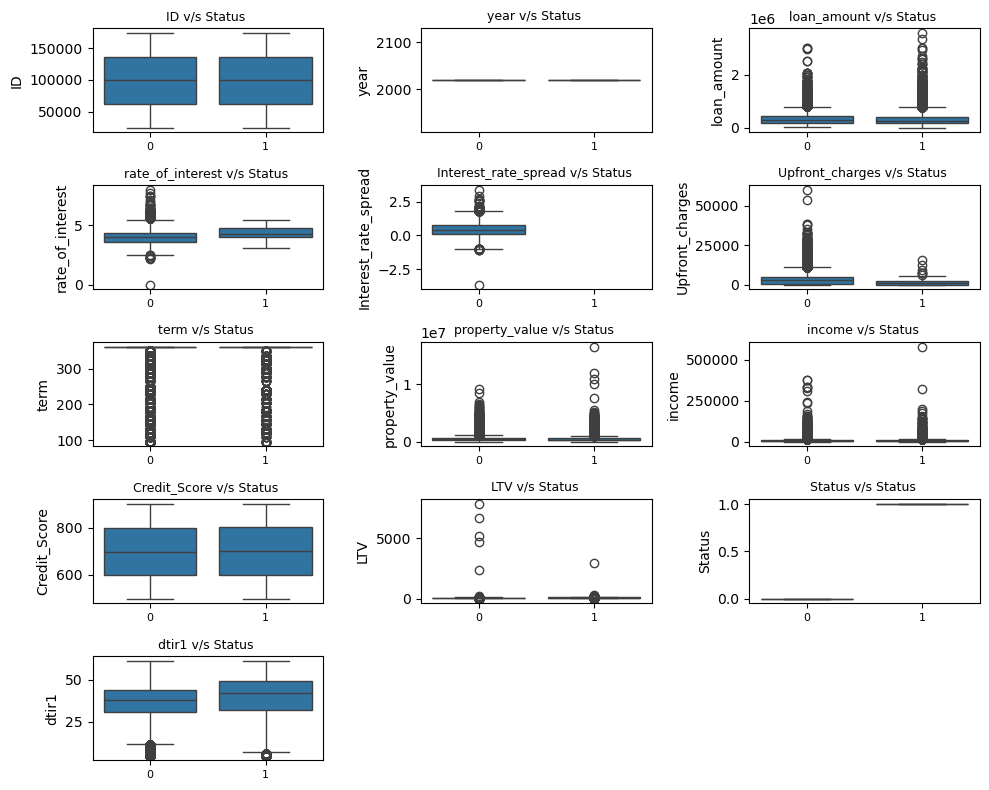

In [40]:
columns = 3
rows = (len(num_column) + columns - 1)//columns
rows
fig, axes = plt.subplots(rows, columns, figsize = (10,8))
axes = axes.flatten()

for i,col in enumerate(num_column):
    sns.boxplot(data = df, x = 'Status', y = col, ax = axes[i])
    axes[i].set_title(f'{col} v/s Status ', fontsize=9)
    axes[i].set_ylabel(f'{col}')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=8)

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Observations:
- Credit Score, ID, property_value and term gives weak signal in relation to predict target. 
- Income, LTV, dtir1, upfront charges and rate of interest have strong signal to predict target. However as investigated, rate of interest have MNAR type of missing values. First, Missing values need to be handled before using this feature.
- Interest rate spread has no data for defaulters. This feature can be dropped.

In [101]:
## Let's check the strength of each feature relation with binary target.
from scipy.stats import mannwhitneyu

# weak signal (test to confirm statistically)
weak_signal = ['Credit_Score', 'property_value', 'term', 'ID','loan_amount', 'year'] 

# Strong signal (test to confirm statistically)
strong_signal = ['income', 'LTV', 'dtir1', 'Upfront_charges', 'rate_of_interest']

test_col = weak_signal + strong_signal

result = []

for col in test_col:
    temp = df[['Status', col]].dropna()
    group0 = temp[temp['Status'] == 0][col]
    group1 = temp[temp['Status'] == 1][col]

    stat, p = mannwhitneyu(group0, group1, alternative = 'two-sided')

    n0, n1 = len(group0), len(group1)
    effect = abs(1 - (2 * stat) / (n0*n1))

    if p >= 0.05:
        decision = 'drop'
    elif effect < 0.1:
        decision = 'Weak - consider drop'
    elif effect < 0.3:
        decision = 'Medium - Keep'
    else:
        decision = 'Strong - Keep'

    result.append({'Feature' : col,
                   'p-value' : round(p,5),
                   'effect_size' : round(effect,4),
                   'decision' : decision})


result_df = pd.DataFrame(result).sort_values('effect_size',ascending = False)
print(result_df.to_string(index=False))
    

         Feature  p-value  effect_size             decision
 Upfront_charges  0.00000       0.3504        Strong - Keep
rate_of_interest  0.00000       0.3156        Strong - Keep
          income  0.00000       0.1846        Medium - Keep
  property_value  0.00000       0.1690        Medium - Keep
           dtir1  0.00000       0.1494        Medium - Keep
             LTV  0.00000       0.1415        Medium - Keep
     loan_amount  0.00000       0.0922 Weak - consider drop
            term  0.00000       0.0154 Weak - consider drop
    Credit_Score  0.12434       0.0053                 drop
              ID  0.51138       0.0023                 drop
            year  1.00000       0.0000                 drop


#### Above table tells which feature to keep and which one to delete.

In [42]:
print(f"{'Column':<35} {'Min default%':>13} {'Max default%':>13} {'Spread':>10} {'Signal':>10}")
print("-"*85)

overall = round(df['Status'].mean()*100, 2)

for col in object_column:
    rates = (df.groupby(col)['Status'].mean()*100).round(2)
    spread = rates.max() - rates.min()
    signal = 'Strong' if spread > 10 else ('Moderate' if spread > 5 else 'Weak')
    print(f"{col:<35} {rates.min():>13.2f} {rates.max():>13.2f} {spread:>10.2f} {signal:>10}")

Column                               Min default%  Max default%     Spread     Signal
-------------------------------------------------------------------------------------
loan_limit                                  23.97         33.21       9.24   Moderate
Gender                                      19.16         28.59       9.43   Moderate
approv_in_adv                               20.89         25.33       4.44       Weak
loan_type                                   22.77         34.54      11.77     Strong
loan_purpose                                22.97         33.08      10.11     Strong
Credit_Worthiness                           24.33         31.77       7.44   Moderate
open_credit                                 17.63         24.67       7.04   Moderate
business_or_commercial                      23.04         34.54      11.50     Strong
Neg_ammortization                           22.38         44.60      22.22     Strong
interest_only                               24.51     

## Observation:
- Approv_in_adv and Interest_only are the only columns with spread < 5 percentage points across all its categories adds very little predictive value and may be a candidate for dropping.

In [43]:
# Checking relationship between Categorical features to the target column
# Chi-squared and CramerV test of each column
from scipy.stats import chi2_contingency
n = len(df)

record = []

for col in object_column:
    contingency = pd.crosstab(index = [df[col]], columns = [df['Status']])
    chi2, p_val, dof, _ = chi2_contingency(contingency)
    cramerV = np.sqrt(chi2/(n*(min(contingency.shape) - 1)))
    status = 'undefined'
    if 0.00 <= cramerV < 0.05:
        status = 'negligible'
    elif 0.05 <= cramerV < 0.10:
        status = 'weak'
    elif 0.10 <= cramerV < 0.20:
        status = 'moderate'
    elif 0.20 <= cramerV:
        status = 'strong'

    record.append({'Column': col, 'chi_sqr': round(chi2,2), 'p_val': p_val, 'dof': dof, 'Crammer_V': round(cramerV,3), 'Status': status})

Result = pd.DataFrame(record).sort_values('Crammer_V', ascending = False)
Result

,Column,chi_sqr,p_val,dof,Crammer_V,Status
15,credit_type,52135.28,0.000000e+00,3,0.592,strong
10,lump_sum_payment,5237.83,0.000000e+00,1,0.188,moderate
8,Neg_ammortization,3610.21,0.000000e+00,1,0.156,moderate
16,co-applicant_credit_type,3092.39,0.000000e+00,1,0.144,moderate
18,submission_of_application,2171.71,0.000000e+00,1,0.121,moderate
3,loan_type,1309.96,3.517253e-285,2,0.094,weak
7,business_or_commercial,1272.81,9.172191e-279,1,0.093,weak
1,Gender,1043.60,6.260048e-226,3,0.084,weak
0,loan_limit,427.40,5.985647e-95,1,0.054,weak
19,Region,380.46,3.786057e-82,3,0.051,weak


## Observation:
- p-value for all the categorical features is less than 0.5, indicating features are not independent.
- All categorical features show statistically significant association with 'Status' (p<0.05) for all columns. However, with 148670 rows, even a negligible relationship produce very low p-value. Cramer's V is required to distinguish columns with genuine predictive signal from those with statistically significant relation but practically meaningless association.
- Cramer's V output:
 - Credit_type has the strong relation with the Status column.
 - Neg_ammortization, lump_sum_payment, co-applicant_credit_type, and submission_of_application have moderate realtion with the Status column.
 - Loan_limit, Gender, Loan_type, business_or_commercial, age and Region have weak relation.
 - Approv_in_adv, loan_purpose, Credit_worthiness, Open_credit, Interest_only, Construction_type, Occupancy_type, Secured_by, total_units, and Security_Type have negligible relation with Status column.
  

In [44]:
def compute_iv_woe(df,col,target):
    total_events = df[target].sum()
    total_nonevents = (1 - df[target]).sum()
    iv = 0 
    woe = 0
    result = []
    for cat in df[col].dropna().unique():
        mask = df[col] == cat
        events = df.loc[mask,target].sum()
        non_events = mask.sum() - events # or df.loc[~mask,target].sum()
        dist_e = events / total_events
        dist_ne = non_events / total_nonevents
        if dist_e == 0 or dist_ne == 0:
            continue
        woe = np.log(dist_e/dist_ne) if dist_e > 0 and dist_ne > 0 else 0
        iv += (dist_e - dist_ne) * woe
        result.append({'Category': cat, 'WoE': round(woe,4)})

    
    predPower = 'N/A'
    if iv < 0.02:
        predPower = 'Useless'
    elif 0.02 <= iv < 0.1:
        predPower = 'Weak predictors'
    elif 0.1 <= iv < 0.3:
        predPower = 'Medium predictors'
    elif 0.3 <= iv < 0.5:
        predPower = 'Strong Predictors'
    elif iv >= 0.5:
        predPower = 'Suspicious'
    
    return iv, pd.DataFrame(result).sort_values('WoE', ascending = False), predPower

result = []
for col in object_column:
    iv, _, predPower = compute_iv_woe(df,col,'Status')
    
        
    result.append({'Column' : col, 'IV': iv, 'Predictive_Power': predPower})

record = pd.DataFrame(result).sort_values('IV', ascending = False)
record

,Column,IV,Predictive_Power
15,credit_type,4.715143e+00,Suspicious
10,lump_sum_payment,1.579800e-01,Medium predictors
16,co-applicant_credit_type,1.139378e-01,Medium predictors
8,Neg_ammortization,1.122522e-01,Medium predictors
18,submission_of_application,8.378772e-02,Weak predictors
3,loan_type,4.359458e-02,Weak predictors
7,business_or_commercial,4.221134e-02,Weak predictors
1,Gender,3.939964e-02,Weak predictors
0,loan_limit,1.418742e-02,Useless
19,Region,1.375577e-02,Useless


In [45]:
overall_result = Result[['Column','Crammer_V','Status']].merge(
    record[['Column','IV','Predictive_Power']],
    on = 'Column',
    how = 'inner'
).sort_values('IV', ascending = False)
overall_result

,Column,Crammer_V,Status,IV,Predictive_Power
0,credit_type,0.592,strong,4.715143e+00,Suspicious
1,lump_sum_payment,0.188,moderate,1.579800e-01,Medium predictors
3,co-applicant_credit_type,0.144,moderate,1.139378e-01,Medium predictors
2,Neg_ammortization,0.156,moderate,1.122522e-01,Medium predictors
4,submission_of_application,0.121,moderate,8.378772e-02,Weak predictors
5,loan_type,0.094,weak,4.359458e-02,Weak predictors
6,business_or_commercial,0.093,weak,4.221134e-02,Weak predictors
7,Gender,0.084,weak,3.939964e-02,Weak predictors
8,loan_limit,0.054,weak,1.418742e-02,Useless
9,Region,0.051,weak,1.375577e-02,Useless


## Observation:
- Credit_type is far from suspicion limits. This tells Data leakage investigation. We need to cross check Credit_type is available at loan application time, not filled after default occur. If this feature is genuine, it is an extremely powerful feature.
- Lump_sum_payment, co-applicant_credit_type, and Neg_ammortization are the medium predictor. important features.
- Submission_of_application, loan_type, business_of_commercial and Gender are weak predictors. Include in model but do not rely heavily on them.
- 13 columns have IV below 0.02 — effectively useless for predicting default. These are strong candidates for dropping during feature selection.

### Let's check Data leakage for Credit_type

In [91]:
df.groupby('credit_type')['Status'].mean().sort_values(ascending = False)

credit_type
EQUI    0.999935
CRIF    0.162343
EXP     0.159854
CIB     0.158041
Name: Status, dtype: float64

In [92]:
# Does credit_type distribution look fundamentally different between classes?
pd.crosstab(df['credit_type'], df['Status'], normalize='index').round(3)

Status,0,1
credit_type,,
CIB,0.842,0.158
CRIF,0.838,0.162
EQUI,0.000,1.000
EXP,0.840,0.160


In [93]:
# interest_rate_spread was zero for all defaulters — clearly post-default
# Check if credit_type and interest_rate_spread are strongly associated
pd.crosstab(df['credit_type'], df['Interest_rate_spread'].isna())

Interest_rate_spread,False,True
credit_type,,
CIB,40542,7610
CRIF,36774,7127
EQUI,1,15297
EXP,34714,6605


### Observation: 
- EQUI has maximum number of default rates (99.9 %). And EQUI perfectly separates defaulters from non-defaulters.
- Also, Interest_rate_spread has no data of defaulters and EQUI is assigned to those rows, indicating EQUI is assigned or recorded after default occurred, not a application time.
- Recommendation: Either EQUI could be neutralized or the whole column will be dropped (Safest). 

# Step 11: Inter-feature correlation & multi-collinearity

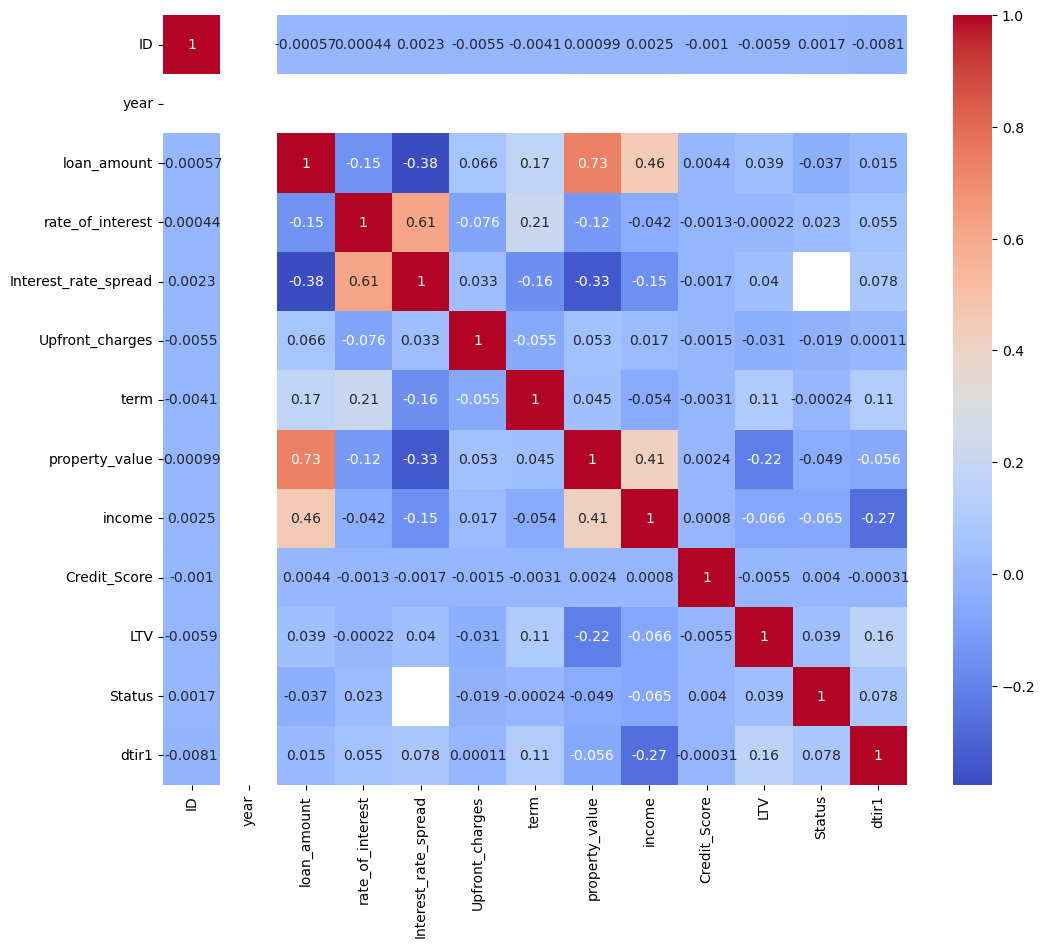

In [46]:
plt.figure(figsize = (12,10))
sns.heatmap(df[num_column].corr(), annot = True, cmap = 'coolwarm')
plt.show()

## Observation:
- LTV has strong negative linear relationship with property value, which is obvious as property value increases risk of loan default, basically LTV decreases.
- dtir1 has strong negative linear relationship with income, indicating lesser risk of loan default (decrease in dtir) if income increases.
- Income and property value have moderate linear relationship. Higher income individuals buy high value property.
- Interest rate spread and property value are inversely proportional to each other, indicating premium properties goes to low risk borrowers.
- High amount loans are sanctioned to high income individuals (corr = 0.46).
- Individuals possessing premium properties are eligible to get high loan amount (corr = 0.73).
- Usually Larger loans tend to have longer repayment term. Here correlation chart shows weak linear relation (corr = 0.17) between term and loan amount.
- Longer term loans generally have high rate of interest. However, the correlation chart tells weak positive relation (corr = 0.22).
- Upfront charges have neutral relation with other feaatures.
- Interest rate spread has a moderate linear relationship with rate of interest (corr = 0.61) as usual because high rate of interest points to high interest rate spread and high profitability.
- Rate of Interest and loan amount are negatively related, which is obvious as high amount secured loans are given at low interest rates. However, they have weak linear relation (corr = -0.15), indicating this loan amount could also contain unsecured loans as well.

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = [c for c in df.select_dtypes(include='number').columns
            if c not in ['ID', 'year', 'Status']]

df_vif = df[num_cols].dropna()

records = []
for i, col in enumerate(num_cols):
    vif = variance_inflation_factor(df_vif.values, i)
    if vif > 10:   level = 'HIGH — problematic'
    elif vif > 5:  level = 'MODERATE — monitor'
    else:          level = 'OK'
    records.append({'column': col, 'VIF': round(vif,2), 'level': level})

pd.DataFrame(records).sort_values('VIF', ascending=False)

,column,VIF,level
1,rate_of_interest,75.95,HIGH — problematic
4,term,44.47,HIGH — problematic
8,LTV,35.55,HIGH — problematic
7,Credit_Score,29.45,HIGH — problematic
0,loan_amount,20.09,HIGH — problematic
9,dtir1,16.68,HIGH — problematic
5,property_value,15.27,HIGH — problematic
2,Interest_rate_spread,3.85,OK
6,income,3.49,OK
3,Upfront_charges,2.07,OK


## Observations:
- Rate_of_interest, term, LTV, Credit_Score, loan_amount, dtir1 and property_value have very high Variation Inflation factor (VIF), indicating high multicollinearity.
- Interest rate spread is derived from rate of interest. Hence, Interest rate spread can be dropped. But final decision of dropping will be based on domain knowledge.
- LTV has medium relation with the target feature. However, it is calculated from loan_amount and income, which also have medium relation with target feature. LTV has high collinearity, therefore this feature can be dropped.
- Although high VIF value of dtir1 indicates multicollinearity and suggests dropping the column, dtir1 is a standard risk metric and important feature for evaluating the risk tendency of a loan. This is also supported by Mann-WhitneyU test for feature target correlation. Hence, dtir1 will be retained as feature for model prediction.
- Credit score has high VIF value and weak relation with target column, indicating dropping of the feature. However, Credit score is an important parameter and domain knowledge needs to be applied before dropping the feature.
- ID and year column will be dropped for model prediction.
- Property value feature will be retained, even if it has high VIF value (means multicollinearity).

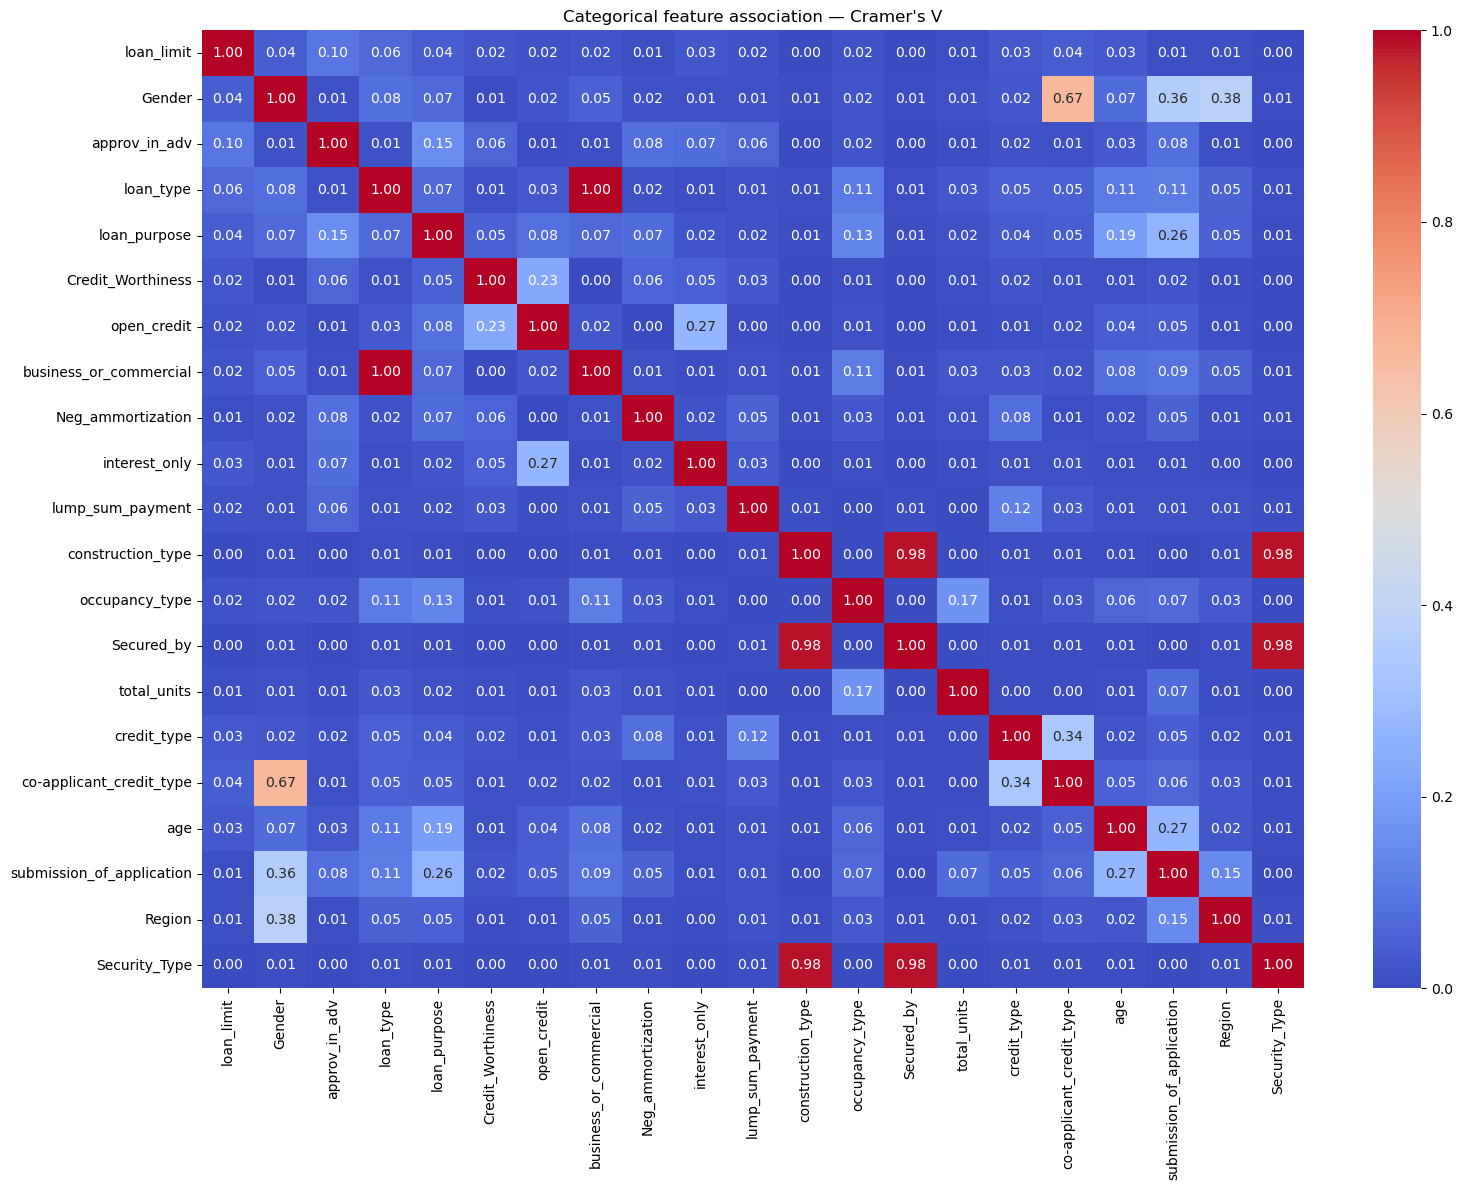

In [48]:
## Let's check the relationship between object columns 

from scipy.stats import chi2_contingency

def cramers_v(col1, col2):
    contingency    = pd.crosstab(col1, col2)
    chi2, _, _, _  = chi2_contingency(contingency)
    n              = len(col1)
    return np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))

# Build association matrix
cat_assoc = pd.DataFrame(index=object_column, columns=object_column, dtype=float)

for col1 in object_column:
    for col2 in object_column:
        if col1 == col2:
            cat_assoc.loc[col1, col2] = 1.0
        else:
            # Drop rows where either column is NaN
            valid = df[[col1, col2]].dropna() #When building a pairwise association matrix, 
            #you must drop rows where either column is NaN before computing Cramer's V for that pair. 
            # If you do not, NaN gets treated as its own category in the crosstab, inflating the association artificially.
            cat_assoc.loc[col1, col2] = cramers_v(valid[col1], valid[col2])

cat_assoc = cat_assoc.astype(float)

# Plot
plt.figure(figsize=(16, 12))
sns.heatmap(cat_assoc, annot=True, fmt='.2f',
            cmap='coolwarm', vmin=0, vmax=1)
plt.title('Categorical feature association — Cramer\'s V')
plt.tight_layout()
plt.show()

## Observation:
- Loan_type and business_or_commercial are highly correlated to each other. Since, both are weak predictors as well, anyone of them could be dropped as feature. Final decision would be based on domain knowledge.
- Construction_type and Security_Type are highly related to each other and are useless as per prediction power. Dropping anyone of them could be dropped.
- Either Secured by or Security type can be dropped as crammer's V is 0.98, indicating high multicollinearity and negligible additional predictive power.